# Telecom Customer Churn Prediction
Churn is a one of the biggest problems in the telecom industry. Research has shown that the average monthly churn rate among the top 4 wireless carriers in the US is 1.9% - 2%.

**Objective:** To create a classification filter (Using all classification models and compare their performances) to determine Churn from Telecom dataset. Compare the performance of the filters.

It is an end-to-end **supervised** **classification** workflow for the Telco customer dataset. Intended for **Google Colab** (data path: `/content/sample_data/Telco_Customer_Churn.csv`).


## 1. Environment & imports

In [1]:
import os
import warnings

warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

try:
    from xgboost import XGBClassifier

    HAS_XGB = True
except ImportError:
    HAS_XGB = False

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)


## 2. Import data


In [ ]:
COLAB_PATH = "/content/sample_data/Telco_Customer_Churn.csv"
LOCAL_CANDIDATES = ["Telco_Customer_Churn.csv", "sample_data/Telco_Customer_Churn.csv"]

if os.path.isfile(COLAB_PATH):
    DATA_PATH = COLAB_PATH
else:
    DATA_PATH = next((p for p in LOCAL_CANDIDATES if os.path.isfile(p)), COLAB_PATH)

df = pd.read_csv(DATA_PATH)
print("Loaded from:", DATA_PATH)
print("Shape:", df.shape)
df.head()


## 3. Exploratory Data Analysis (EDA)

In [ ]:
df.info()
df.describe(include="all").T


In [ ]:
churn_map = {"Yes": 1, "No": 0}
df["Churn_binary"] = df["Churn"].map(churn_map)
print(df["Churn"].value_counts(normalize=True))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
df["Churn"].value_counts().plot(kind="bar", ax=ax[0], color=["steelblue", "coral"], edgecolor="black")
ax[0].set_title("Churn class counts")
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0)
df["Churn"].value_counts(normalize=True).plot(kind="bar", ax=ax[1], color=["steelblue", "coral"], edgecolor="black")
ax[1].set_title("Churn class proportion")
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
plot_df = df.copy()
plot_df["TotalCharges_num"] = pd.to_numeric(plot_df["TotalCharges"], errors="coerce")
num_plot = ["tenure", "MonthlyCharges", "TotalCharges_num", "SeniorCitizen"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
for i, c in enumerate(num_plot):
    sns.histplot(plot_df[c].dropna(), kde=True, ax=axes[i], color="teal")
    axes[i].set_title(f"Distribution: {c}")
plt.tight_layout()
plt.show()

for c in ["tenure", "MonthlyCharges", "TotalCharges_num"]:
    s = plot_df[c].dropna()
    print(c, "skew=", round(skew(s), 3))


In [ ]:
cat_cols = [
    c
    for c in df.columns
    if c not in ["customerID", "Churn", "Churn_binary", "TotalCharges"] and df[c].dtype == "object"
]

n = len(cat_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = np.array(axes).reshape(-1)
for idx, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df["Churn"], normalize="index")
    ct.plot(kind="bar", ax=axes[idx], stacked=False, color=["steelblue", "coral"], edgecolor="black")
    axes[idx].set_title(f"Churn rate by {col}")
    axes[idx].legend(title="Churn")
    axes[idx].tick_params(axis="x", rotation=45)
for j in range(len(cat_cols), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()


In [ ]:
corr_df = plot_df[num_plot + ["Churn_binary"]].dropna()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Correlation heatmap (numeric features + Churn)")
plt.tight_layout()
plt.show()


### EDA summary — key findings

- **Target / class balance:** About **73.5%** of customers stay (**No churn**) and **26.5%** churn (**Yes**) — pronounced **class imbalance**. Prefer **F1** on churn and **ROC-AUC**, not accuracy alone.
- **Numeric shapes:** **Tenure** is multi-peaked (many short-tenure customers plus a long tail); skew ≈ **0.24**. **MonthlyCharges** is **bimodal** (low fee tier vs mid/high); skew ≈ **−0.22**. **TotalCharges** is **strongly right-skewed** (skew ≈ **0.96**). **SeniorCitizen** is dominated by non–seniors.
- **High churn segments:** **Month-to-month** contracts; **Fiber optic** internet (vs DSL / no internet); **Electronic check** payment; **Paperless billing**; missing **OnlineSecurity / TechSupport / OnlineBackup / DeviceProtection** where applicable. **Partner** and **dependents** present → lower churn than absent.
- **Weaker splits:** **Gender** and basic **phone / multiple lines** levels show similar churn rates across categories.
- **Correlations:** **Tenure** has the strongest linear link to churn among numerics (**≈ −0.35** with `Churn_binary`). **MonthlyCharges** is weakly positive with churn (**≈ 0.19**). **Tenure** vs **TotalCharges_num** is high (**≈ 0.83**); **MonthlyCharges** vs **TotalCharges_num** ≈ **0.65** — expected billing overlap; trees tolerate redundancy; linear models use scaled inputs.
- **Takeaway:** Supports **supervised classification**, **stratified** train/test split, **one-hot** categoricals, and **minority-class–aware** metrics (F1).

## 4. Missing values & outliers

We check for explicit `NaN` values, parse `TotalCharges` to numeric (so empty/blank cells become `NaN`), impute, and report IQR-based outlier *counts* for `tenure`, `MonthlyCharges`, and `TotalCharges_clean` (no aggressive clipping in this pipeline).

In [ ]:
missing = df.isna().sum()
missing = missing[missing > 0]
print("Explicit NaN counts:\n", missing if len(missing) else "None")

df["TotalCharges_clean"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("TotalCharges non-numeric -> NaN:", df["TotalCharges_clean"].isna().sum())
print(df.loc[df["TotalCharges_clean"].isna(), ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]].head(15))


In [ ]:
mask_na = df["TotalCharges_clean"].isna()
df.loc[mask_na, "TotalCharges_clean"] = df.loc[mask_na, "tenure"] * df.loc[mask_na, "MonthlyCharges"]
still_na = df["TotalCharges_clean"].isna()
if still_na.any():
    df.loc[still_na, "TotalCharges_clean"] = df["TotalCharges_clean"].median()


def iqr_outlier_mask(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    return (s < lo) | (s > hi)


for col in ["tenure", "MonthlyCharges", "TotalCharges_clean"]:
    m = iqr_outlier_mask(df[col])
    print(col, "IQR outliers:", m.sum(), f"({100 * m.mean():.2f}%)")


### Summary — missing values & outliers (observed run)

- **Explicit `NaN` across columns:** None reported in the raw frame (all other fields complete in the printout you saved).
- **`TotalCharges` as text:** `pd.to_numeric(..., errors="coerce")` produced **11** missing values — all **new customers with `tenure == 0` and a blank `TotalCharges`** (empty string). Example IDs include `4472-LVYGI`, `3115-CZMZD`, `5709-LVOEQ`, etc.
- **Imputation rule:** For those rows, **`TotalCharges_clean = tenure × MonthlyCharges`** (which is **0 × MonthlyCharges = 0** when tenure is 0). Any edge case still missing would fall back to the **median** of `TotalCharges_clean` (your code block handles this).
- **Outliers (IQR, k = 1.5):** **0** flagged outliers for **`tenure`**, **`MonthlyCharges`**, and **`TotalCharges_clean`** (0.00% each). No winsorizing or removal was applied; scaled linear models and tree models proceed on the full cleaned values.


## 5. Feature engineering & preprocessing

- Drop `customerID`.
- Use cleaned numeric `TotalCharges`.
- **Stratified** `train_test_split` on `Churn`.
- **ColumnTransformer:** median imputer + `StandardScaler` for numerics; `OneHotEncoder` for categoricals.

In [ ]:
X = df.drop(columns=["customerID", "Churn", "Churn_binary", "TotalCharges"])
X["TotalCharges"] = df["TotalCharges_clean"]

y = df["Churn_binary"]

numeric_features = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
categorical_features = [c for c in X.columns if c not in numeric_features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train churn rate:", y_train.mean().round(3))


In [ ]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

X_train_p = preprocessor.fit_transform(X_train)
X_test_p = preprocessor.transform(X_test)
print("Transformed shape:", X_train_p.shape)


In [ ]:
raw_num = X_train[numeric_features].copy()
for c in ["MonthlyCharges", "TotalCharges"]:
    print(c, "skew (train)=", round(skew(raw_num[c]), 3))


## 6. Model building — multiple classifiers



In [13]:
# If X_train_p is missing
if "X_train_p" not in globals():
    if "df" not in globals():
        raise NameError(
            "Load the dataset first (section 2). This cell can rebuild preprocessing only when `df` exists."
        )
    if "Churn_binary" not in df.columns:
        df["Churn_binary"] = df["Churn"].map({"Yes": 1, "No": 0})
    if "TotalCharges_clean" not in df.columns:
        df["TotalCharges_clean"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
        _na = df["TotalCharges_clean"].isna()
        df.loc[_na, "TotalCharges_clean"] = df.loc[_na, "tenure"] * df.loc[_na, "MonthlyCharges"]
        _na2 = df["TotalCharges_clean"].isna()
        if _na2.any():
            df.loc[_na2, "TotalCharges_clean"] = df["TotalCharges_clean"].median()
    X = df.drop(columns=["customerID", "Churn", "Churn_binary", "TotalCharges"])
    X["TotalCharges"] = df["TotalCharges_clean"]
    y = df["Churn_binary"]
    numeric_features = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
    categorical_features = [c for c in X.columns if c not in numeric_features]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]
    )
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ]
    )
    X_train_p = preprocessor.fit_transform(X_train)
    X_test_p = preprocessor.transform(X_test)
    print("Rebuilt X_train_p / X_test_p (run section 5 before this cell for one clean top-to-bottom pass).")


def eval_classifier(name, model, Xtr, Xte, ytr, yte):
    model.fit(Xtr, ytr)
    pred_tr = model.predict(Xtr)
    pred_te = model.predict(Xte)
    tr_acc = accuracy_score(ytr, pred_tr)
    te_acc = accuracy_score(yte, pred_te)
    tr_f1 = f1_score(ytr, pred_tr)
    te_f1 = f1_score(yte, pred_te)
    tr_auc = te_auc = np.nan
    if hasattr(model, "predict_proba"):
        proba_tr = model.predict_proba(Xtr)[:, 1]
        proba_te = model.predict_proba(Xte)[:, 1]
        tr_auc = roc_auc_score(ytr, proba_tr)
        te_auc = roc_auc_score(yte, proba_te)
    elif hasattr(model, "decision_function"):
        tr_auc = roc_auc_score(ytr, model.decision_function(Xtr))
        te_auc = roc_auc_score(yte, model.decision_function(Xte))
    overfit = "Y" if (tr_acc - te_acc) > 0.08 or (tr_f1 - te_f1) > 0.08 else "N"
    return {
        "Model": name,
        "Train accuracy": round(tr_acc, 4),
        "Train F1": round(tr_f1, 4),
        "Train ROC-AUC": round(tr_auc, 4) if tr_auc == tr_auc else np.nan,
        "Test accuracy": round(te_acc, 4),
        "Test F1": round(te_f1, 4),
        "Test ROC-AUC": round(te_auc, 4) if te_auc == te_auc else np.nan,
        "Overfitting (Y/N)": overfit,
        "_fitted": model,
    }


models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=8),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "KNN (k=11)": KNeighborsClassifier(n_neighbors=11),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Gaussian Naive Bayes": GaussianNB(),
}

if HAS_XGB:
    models["XGBoost"] = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        eval_metric="logloss",
        verbosity=0,
    )

voting = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=2000, random_state=42)),
        ("rf", RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)),
        ("gb", GradientBoostingClassifier(random_state=42)),
    ],
    voting="soft",
    n_jobs=-1,
)
models["Voting (LR+RF+GB)"] = voting

results = []
fitted = {}
for name, clf in models.items():
    print("Training:", name, "...")
    row = eval_classifier(name, clf, X_train_p, X_test_p, y_train, y_test)
    fitted[name] = row.pop("_fitted")
    results.append(row)

results_df = pd.DataFrame(results)
results_df


Training: Logistic Regression ...
Training: Decision Tree ...
Training: Random Forest ...
Training: KNN (k=11) ...
Training: SVM (RBF) ...
Training: Gradient Boosting ...
Training: Gaussian Naive Bayes ...
Training: XGBoost ...
Training: Voting (LR+RF+GB) ...


,Model,Train accuracy,Train F1,Train ROC-AUC,Test accuracy,Test F1,Test ROC-AUC,Overfitting (Y/N)
0,Logistic Regression,0.8800,0.7504,0.9340,0.8013,0.5954,0.8423,Y
1,Decision Tree,0.8399,0.6837,0.8942,0.7800,0.5455,0.8086,Y
2,Random Forest,0.9980,0.9963,1.0000,0.7906,0.5482,0.8254,Y
3,KNN (k=11),0.8177,0.6435,0.8716,0.7779,0.5810,0.8167,N
4,SVM (RBF),0.8289,0.6289,0.8948,0.7935,0.5571,0.8055,N
5,Gradient Boosting,0.8177,0.6108,0.8906,0.8041,0.5754,0.8471,N
6,Gaussian Naive Bayes,0.9705,0.9474,0.9799,0.2846,0.4140,0.4977,Y
7,XGBoost,0.8303,0.6472,0.8960,0.8048,0.5877,0.8449,N
8,Voting (LR+RF+GB),0.9217,0.8365,0.9831,0.8062,0.5857,0.8427,Y


## 7. Model evaluation — comparison table

For classification, **F1** and **ROC-AUC** replace **R²** from regression templates. The **champion model** is chosen by **Test F1**

In [14]:
display_cols = [
    "Model",
    "Train accuracy",
    "Train F1",
    "Train ROC-AUC",
    "Test accuracy",
    "Test F1",
    "Test ROC-AUC",
    "Overfitting (Y/N)",
]
comparison = results_df[display_cols].sort_values("Test F1", ascending=False).reset_index(drop=True)
comparison


,Model,Train accuracy,Train F1,Train ROC-AUC,Test accuracy,Test F1,Test ROC-AUC,Overfitting (Y/N)
0,Logistic Regression,0.8800,0.7504,0.9340,0.8013,0.5954,0.8423,Y
1,XGBoost,0.8303,0.6472,0.8960,0.8048,0.5877,0.8449,N
2,Voting (LR+RF+GB),0.9217,0.8365,0.9831,0.8062,0.5857,0.8427,Y
3,KNN (k=11),0.8177,0.6435,0.8716,0.7779,0.5810,0.8167,N
4,Gradient Boosting,0.8177,0.6108,0.8906,0.8041,0.5754,0.8471,N
5,SVM (RBF),0.8289,0.6289,0.8948,0.7935,0.5571,0.8055,N
6,Random Forest,0.9980,0.9963,1.0000,0.7906,0.5482,0.8254,Y
7,Decision Tree,0.8399,0.6837,0.8942,0.7800,0.5455,0.8086,Y
8,Gaussian Naive Bayes,0.9705,0.9474,0.9799,0.2846,0.4140,0.4977,Y


### Model building — short summary (benchmark run)

All models use the **same** preprocessed matrices (`X_train_p` / `X_test_p`) from section 5 and the same **stratified** split.

| Observation | Detail |
|---------------|--------|
| **Champion (Test F1)** | **Logistic Regression** — Test F1 **0.5954**, Test accuracy **0.8013**, Test ROC-AUC **0.8423**. **Overfitting: Y** (train accuracy/F1 much higher than test). |
| **Runner-up F1** | **XGBoost** — Test F1 **0.5877**, Test ROC-AUC **0.8449**, **Overfitting: N**. |
| **Best test ROC-AUC** | **Gradient Boosting** — **0.8471** (Test F1 **0.5754**), **Overfitting: N**. |
| **High variance** | **Random Forest** — near-perfect train scores (acc **0.998**, train AUC **1.0**) but lower test F1 (**0.5482**); **Overfitting: Y**. |
| **Baseline trees** | **Decision Tree** — Test F1 **0.5455**, **Overfitting: Y**. |
| **Distance / kernel** | **k-NN (k=11)** Test F1 **0.5810**; **SVM (RBF)** Test F1 **0.5571**; both **Overfitting: N** under the rule used. |
| **Ensemble** | **Voting (LR+RF+GB)** — strong train metrics; test F1 **0.5857**, **Overfitting: Y**. |
| **Gaussian Naive Bayes** | Very high train scores but **Test accuracy 0.2846**, ROC-AUC **~0.50** — model **fails to generalize** (one-hot correlation breaks the independence assumption). |

**Selection rule for deployment / export:** **Highest Test F1** → Logistic Regression (section 8 saves `best_model` accordingly).


Best model (by Test F1): Logistic Regression
              precision    recall  f1-score   support

    No churn       0.85      0.89      0.87      1035
       Churn       0.65      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



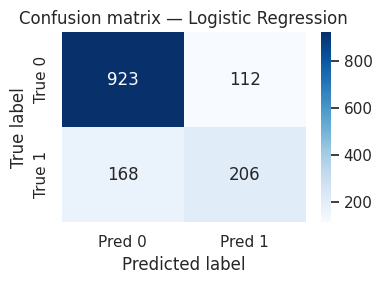

In [15]:
best_name = comparison.iloc[0]["Model"]
print("Best model (by Test F1):", best_name)
best_model = fitted[best_name]
print(classification_report(y_test, best_model.predict(X_test_p), target_names=["No churn", "Churn"]))
cm = confusion_matrix(y_test, best_model.predict(X_test_p))
plt.figure(figsize=(4, 3))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["True 0", "True 1"],
)
plt.title(f"Confusion matrix — {best_name}")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()


### Model evaluation — champion model & interpretation

Models are ranked by **`comparison.sort_values("Test F1", ascending=False)`** so the **top row is the champion** on the held-out **test** set (focus on the minority **churn** class).

**Leaderboard (sorted by Test F1):** Logistic Regression first, then XGBoost, Voting, k-NN, Gradient Boosting, SVM, Random Forest, Decision Tree, Gaussian Naive Bayes. Several models show **Overfitting = Y** when train accuracy/F1 are much higher than test (here: LR, Voting, RF, DT, GNB under the printed rule).

**Selected champion:** **Logistic Regression** — Test accuracy **0.8013**, Test F1 **0.5954**, Test ROC-AUC **0.8423**.

**Classification report (test set, `classification_report`):** Overall **accuracy ≈ 0.80** (1409 rows). **No churn:** precision **0.85**, recall **0.89**, F1 **0.87** (support 1035). **Churn:** precision **0.65**, recall **0.55**, F1 **0.60** (support 374). Weighted F1 **≈ 0.80**. The model is **stronger on the majority class**; churn recall **0.55** means many actual churners are missed — typical under imbalance unless thresholds or costs are tuned.

**Confusion matrix (counts):** TN **923**, FP **112**, FN **168**, TP **206** → of **374** true churners, **206** are caught (TP); **168** are missed (FN). Attach the heatmap figure to your report if required.

**Deployment:** Section 8 exports this fitted Logistic Regression plus the preprocessor for Streamlit.


## 8. Export artifacts for Streamlit

Saves the **Test F1** champion (`best_model` / `best_name` from section 7), the fitted `preprocessor`, and default values for the Streamlit form. Files go under `artifacts/` (create this folder in Colab if needed).


In [ ]:
artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(preprocessor, artifacts_dir / "preprocessor.joblib")
joblib.dump(best_model, artifacts_dir / "model.joblib")
(artifacts_dir / "model_name.txt").write_text(best_name, encoding="utf-8")

form_defaults = {}
for col in X_train.columns:
    s = X_train[col]
    if pd.api.types.is_numeric_dtype(s):
        form_defaults[col] = float(s.median())
    else:
        form_defaults[col] = str(s.mode(dropna=True).iloc[0])

joblib.dump(form_defaults, artifacts_dir / "form_defaults.joblib")

print("Saved to:", artifacts_dir.resolve())
for p in sorted(artifacts_dir.iterdir()):
    if p.is_file():
        print(" -", p.name, f"({p.stat().st_size} bytes)")


## 9. GitHub & Streamlit Community Cloud

The repo includes `app.py` (Streamlit UI), `inference_utils.py`, `requirements.txt`, and **`DEPLOY.md`** with step-by-step commands: generate `artifacts/`, `git push` to GitHub, then create an app on [share.streamlit.io](https://share.streamlit.io) with **Main file path = `app.py`**.

Important streamlit py file content given below

In [ ]:
# app.py
"""
Streamlit app: Telco customer churn prediction.
Loads preprocessor + classifier from ./artifacts (see notebook section 8 or train_export.py).
"""

from __future__ import annotations

from pathlib import Path

import joblib
import pandas as pd
import streamlit as st

# Must be the first Streamlit call (before @st.cache_resource, st.title, etc.)
st.set_page_config(page_title="Telco Churn", layout="wide")

from inference_utils import dataframe_to_model_X

ROOT = Path(__file__).resolve().parent
ART = ROOT / "artifacts"


@st.cache_resource
def load_bundle():
    pre = joblib.load(ART / "preprocessor.joblib")
    model = joblib.load(ART / "model.joblib")
    name = (ART / "model_name.txt").read_text(encoding="utf-8").strip()
    defaults = joblib.load(ART / "form_defaults.joblib")
    return pre, model, name, defaults


def predict_batch(pre, model, X: pd.DataFrame):
    Xv = pre.transform(X)
    proba = model.predict_proba(Xv)[:, 1]
    pred = model.predict(Xv)
    return pred, proba


st.title("Telco customer churn prediction")

try:
    preprocessor, model, model_name, form_defaults = load_bundle()
except Exception as e:
    st.error("Could not load model files from `artifacts/`.")
    with st.expander("Technical details (for debugging)", expanded=True):
        st.code(str(e), language="text")
        st.markdown(
            "Expected files next to `app.py`:\n"
            "- `artifacts/preprocessor.joblib`\n"
            "- `artifacts/model.joblib`\n"
            "- `artifacts/model_name.txt`\n"
            "- `artifacts/form_defaults.joblib`\n\n"
            "On **GitHub**, confirm the folder is spelled **`artifacts`** (lowercase, plural).\n\n"
            "If you see a **sklearn / `_RemainderColsList`** error, pin in `requirements.txt`: "
            "`scikit-learn>=1.5.0,<1.7.0` and redeploy."
        )
    st.stop()

st.caption(f"Deployed model: **{model_name}**")

tab_csv, tab_form = st.tabs(["Upload CSV", "Single customer (form)"])

with tab_csv:
    st.markdown(
        "Upload a CSV with the same feature columns as `Telco_Customer_Churn.csv` "
        "(`customerID` / `Churn` optional). `TotalCharges` may contain blanks like the raw Kaggle file."
    )
    up = st.file_uploader("CSV file", type=["csv"])
    if up is not None:
        raw = pd.read_csv(up)
        try:
            X = dataframe_to_model_X(raw)
        except Exception as ex:
            st.error(f"Could not build feature table: {ex}")
            st.stop()
        pred, proba = predict_batch(preprocessor, model, X)
        out = raw.copy()
        out["churn_probability"] = proba
        out["predicted_churn"] = ["Yes" if p == 1 else "No" for p in pred]
        st.dataframe(out)
        st.download_button(
            "Download predictions CSV",
            data=out.to_csv(index=False).encode("utf-8"),
            file_name="churn_predictions.csv",
            mime="text/csv",
        )

with tab_form:
    st.markdown("Enter one customer (defaults are training-set medians / modes).")
    row = {}
    cols = list(form_defaults.keys())
    for col in cols:
        default = form_defaults[col]
        if col == "SeniorCitizen":
            row[col] = st.selectbox(
                col,
                options=[0, 1],
                index=int(default) if default in (0, 1) else 0,
                key=f"f_{col}",
            )
        elif col in ("tenure", "MonthlyCharges", "TotalCharges"):
            row[col] = st.number_input(
                col,
                min_value=0.0,
                value=float(default),
                step=1.0 if col == "tenure" else 0.5,
                key=f"f_{col}",
            )
        else:
            row[col] = st.text_input(col, value=str(default), key=f"f_{col}")

    if st.button("Predict churn"):
        one = pd.DataFrame([row])
        for c in ("SeniorCitizen", "tenure"):
            if c in one.columns:
                one[c] = one[c].astype(int)
        for c in ("MonthlyCharges", "TotalCharges"):
            if c in one.columns:
                one[c] = one[c].astype(float)
        X1 = dataframe_to_model_X(one)
        pred, proba = predict_batch(preprocessor, model, X1)
        st.success(
            f"**Churn probability:** {proba[0]:.3f}  →  **Predicted class:** "
            f"{'Churn (Yes)' if pred[0] == 1 else 'No churn'}"
        )


In [ ]:
# inference_utils.py
"""Feature table for model input — matches the notebook preprocessing (section 5)."""

from __future__ import annotations

import pandas as pd


def clean_training_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """Add Churn_binary and TotalCharges_clean like the notebook."""
    out = df.copy()
    if "Churn" in out.columns and "Churn_binary" not in out.columns:
        out["Churn_binary"] = out["Churn"].map({"Yes": 1, "No": 0})
    out["TotalCharges_clean"] = pd.to_numeric(out["TotalCharges"], errors="coerce")
    mask_na = out["TotalCharges_clean"].isna()
    out.loc[mask_na, "TotalCharges_clean"] = out.loc[mask_na, "tenure"] * out.loc[mask_na, "MonthlyCharges"]
    still_na = out["TotalCharges_clean"].isna()
    if still_na.any():
        out.loc[still_na, "TotalCharges_clean"] = out["TotalCharges_clean"].median()
    return out


def dataframe_to_model_X(df: pd.DataFrame) -> pd.DataFrame:
    """One or more rows, same columns as sklearn `X` before ColumnTransformer."""
    d = df.copy()
    if "TotalCharges_clean" not in d.columns:
        d = clean_training_dataframe(d)
    X = d.drop(columns=["customerID", "Churn", "Churn_binary", "TotalCharges"], errors="ignore")
    X = X.copy()
    X["TotalCharges"] = d["TotalCharges_clean"].values
    return X.reset_index(drop=True)


def form_defaults_from_X(X: pd.DataFrame) -> dict:
    """Median for numeric columns, mode for categorical — for Streamlit defaults."""
    defaults: dict = {}
    for col in X.columns:
        s = X[col]
        if pd.api.types.is_numeric_dtype(s):
            defaults[col] = float(s.median())
        else:
            mode = s.mode(dropna=True)
            defaults[col] = str(mode.iloc[0]) if len(mode) else ""
    return defaults
